# Supplementary Figure 3: sensitivity to the transposition-associated forward-rate increment

Each row shows finite-time trajectories under fixed relaxed and selected conditions, followed by five transient cycles from the common starting distribution. Maximum PCN capacities are 100, 50, and 20. These panels are finite-time sensitivities, not periodic-attractor analyses.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_3_outputs")
REDUCED_ON_KF=0.0575
FORWARD_INCREMENT=TRANSITIONS.kappa_f_pcn-TRANSITIONS.kappa_f_on
SETTINGS={
    "reduced": dict(kf_on=REDUCED_ON_KF, kb_on=TRANSITIONS.kappa_b_on,
                    kf_combined=REDUCED_ON_KF+FORWARD_INCREMENT, kb_combined=TRANSITIONS.kappa_b_pcn),
    "primary": dict(kf_on=TRANSITIONS.kappa_f_on, kb_on=TRANSITIONS.kappa_b_on,
                    kf_combined=TRANSITIONS.kappa_f_pcn, kb_combined=TRANSITIONS.kappa_b_pcn),
}
SCENARIOS=[("a",100,"reduced"),("b",100,"primary"),("c",50,"reduced"),("d",50,"primary"),("e",20,"reduced"),("f",20,"primary")]

def configs_for(max_pcn,setting):
    s=SETTINGS[setting]
    return [
      make_configuration(max_pcn,condition="transposition off",kappa_f=TRANSITIONS.kappa_f_off,kappa_b=TRANSITIONS.kappa_b_off,setting_label=setting),
      make_configuration(max_pcn,condition="transposition on",kappa_f=s["kf_on"],kappa_b=s["kb_on"],setting_label=setting),
      make_configuration(max_pcn,condition="transposition on + PCN dynamics",kappa_f=s["kf_combined"],kappa_b=s["kb_combined"],setting_label=setting),
    ]


## Simulations and figure


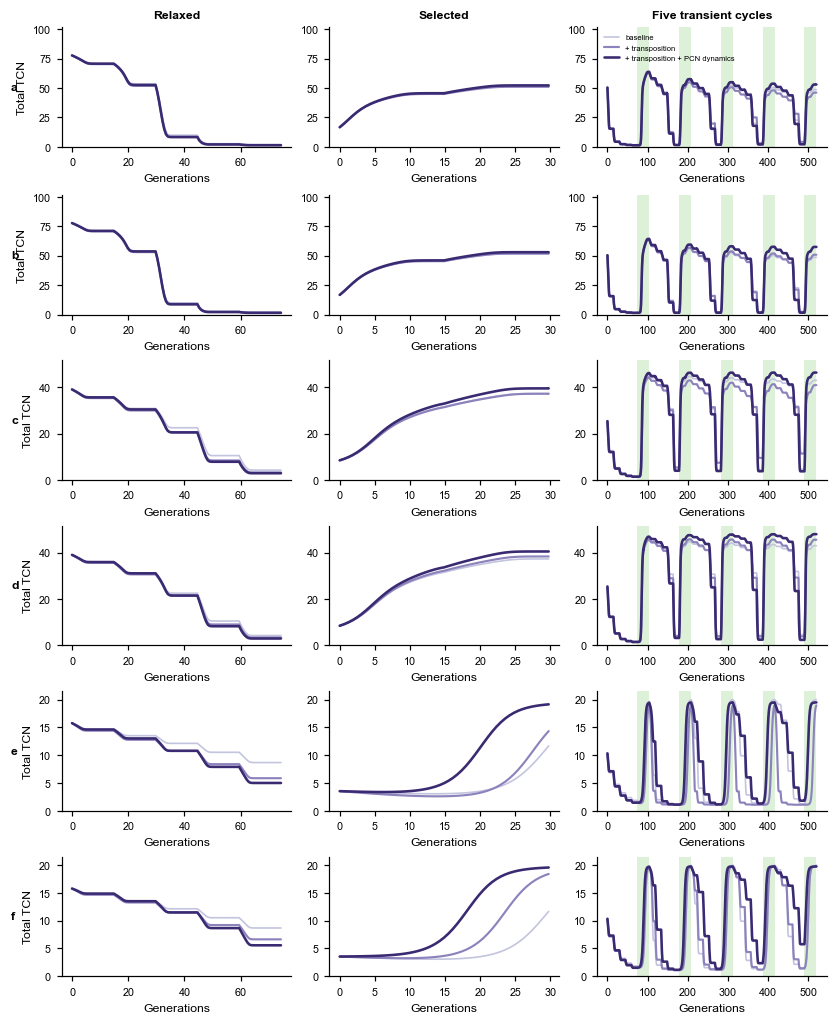

In [2]:
fixed={}; transient={}; cycle_tables=[]
for panel,max_pcn,setting in SCENARIOS:
    for config in configs_for(max_pcn,setting):
        for phase,duration,init in (("loss",RELAXED_DAYS_PER_CYCLE,fixed_loss_initial_state(max_pcn)),
                                    ("gain",SELECTED_DAYS_PER_CYCLE,fixed_gain_initial_state(max_pcn))):
            t,_,_,_=simulate_phase(max_pcn,config,phase=phase,duration_days=duration,initial_state=init,record_trajectory=True)
            fixed[(panel,phase,config.condition)]=t
        t,_,ct=simulate_transient_cycles(max_pcn,config,cycles=TRANSIENT_CYCLES)
        transient[(panel,config.condition)]=t
        ct["panel"]=panel; cycle_tables.append(ct)

fig,axes=plt.subplots(6,3,figsize=(7.5,9.2),constrained_layout=True)
for j,title in enumerate(("Relaxed","Selected","Five transient cycles")): axes[0,j].set_title(title,fontweight="bold")
for r,(panel,max_pcn,setting) in enumerate(SCENARIOS):
    cfgs=configs_for(max_pcn,setting)
    for j,phase in enumerate(("loss","gain")):
        for c in cfgs:
            d=fixed[(panel,phase,c.condition)]
            axes[r,j].plot(d.phase_day*PASSAGE_GENERATIONS,d.TCN_per_density,color=CONDITION_COLORS[c.condition],lw=CONDITION_LINEWIDTHS[c.condition])
        axes[r,j].set_ylim(0,max_pcn+1.5); axes[r,j].set_xlabel("Generations")
        if j==0: axes[r,j].set_ylabel("Total TCN")
    for cyc in range(1,TRANSIENT_CYCLES+1):
        start=(cyc-1)*DAYS_PER_CYCLE+RELAXED_DAYS_PER_CYCLE
        axes[r,2].axvspan(start*PASSAGE_GENERATIONS,(start+SELECTED_DAYS_PER_CYCLE)*PASSAGE_GENERATIONS,color=SELECTION_SHADE,lw=0)
    for c in cfgs:
        d=transient[(panel,c.condition)]
        axes[r,2].plot(d.Day*PASSAGE_GENERATIONS,d.TCN_per_density,color=CONDITION_COLORS[c.condition],lw=CONDITION_LINEWIDTHS[c.condition],label=DISPLAY_LABELS[c.condition])
    axes[r,2].set_ylim(0,max_pcn+1.5); axes[r,2].set_xlabel("Generations")
    axes[r,0].text(-0.22,0.5,panel,transform=axes[r,0].transAxes,fontweight="bold",va="center")
axes[0,2].legend(frameon=False,fontsize=5)
save_figure(fig,"Supplementary_Figure_3_forward_sensitivity",FIGURE_DIR); plt.show()

source=[]
for (panel,phase,condition),d in fixed.items():
    x=d.copy(); x["panel"]=panel; x["analysis"]="fixed"; source.append(x)
for (panel,condition),d in transient.items():
    x=d.copy(); x["panel"]=panel; x["analysis"]="transient"; source.append(x)
export_table(pd.concat(source,ignore_index=True),"Supplementary_Figure_3_source_data.csv",SOURCE_DIR)
export_table(pd.concat(cycle_tables,ignore_index=True),"Supplementary_Figure_3_cycle_endpoints.csv",SOURCE_DIR)
export_table(core_metadata("Supplementary Figure 3"),"Supplementary_Figure_3_run_metadata.csv",SOURCE_DIR)
